## 0. 导入

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data_folder = "./Data/HS300_data"
csv_files = glob.glob(os.path.join(data_folder, '*.csv'))
df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

data = pd.concat(df_list, ignore_index=True)
print(f"数据读取完毕，总行数: {len(data)}")
# data.to_csv("./Data/HS300_data/data.csv", index=False)

数据读取完毕，总行数: 1465200


## 1. 单因子

### 1.1 导入数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data = pd.read_csv("./Data/HS300_data/data.csv")
fund_cols = ['market_cap','basic_eps','pe_ratio','pb_ratio',
            'capitalization','circulating_cap','circulating_market_cap',
            'roe','roa','net_profit_margin','gross_profit_margin',
            'eps','operating_profit','net_profit',
            'inc_revenue_year_on_year','inc_net_profit_year_on_year',
            'inc_operation_profit_year_on_year','inc_total_revenue_year_on_year',
            'inc_net_profit_to_shareholders_year_on_year',
            'ocf_to_revenue','operation_profit_to_total_revenue']
price_cols = ['close', 'open', 'turnover_ratio', 'volume', 'net_pct_xl', 'net_pct_l']
use_cols = ['time', 'code'] + price_cols + fund_cols
df = data[use_cols].copy()

df = df.dropna(subset=['time', 'code'])
df['time'] = pd.to_datetime(df['time'], errors='coerce')
num_cols = price_cols + fund_cols
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df = df.sort_values(['code', 'time']).reset_index(drop=True)
df['ret'] = df.groupby('code')['close'].pct_change()
df[fund_cols] = df.groupby('code')[fund_cols].ffill()
df.head()

,time,code,close,open,turnover_ratio,volume,net_pct_xl,net_pct_l,market_cap,basic_eps,...,operating_profit,net_profit,inc_revenue_year_on_year,inc_net_profit_year_on_year,inc_operation_profit_year_on_year,inc_total_revenue_year_on_year,inc_net_profit_to_shareholders_year_on_year,ocf_to_revenue,operation_profit_to_total_revenue,ret
0,2016-01-04,000001.XSHE,7.64,8.09,0.4774,83611173.0,-18.63,-2.41,1621.1730,0.43,...,7.105000e+09,6.155000e+09,23.39,9.48,8.24,23.39,9.48,-368.38,32.71,NaN
1,2016-01-05,000001.XSHE,7.68,7.60,0.5619,98415241.0,-6.30,-1.05,1631.1891,0.43,...,7.105000e+09,6.155000e+09,23.39,9.48,8.24,23.39,9.48,-368.38,32.71,0.005236
2,2016-01-06,000001.XSHE,7.77,7.70,0.4369,76519934.0,1.99,-1.40,1649.7904,0.43,...,7.105000e+09,6.155000e+09,23.39,9.48,8.24,23.39,9.48,-368.38,32.71,0.011719
3,2016-01-07,000001.XSHE,7.37,7.69,0.1481,25930853.0,-39.15,4.30,1565.3691,0.43,...,7.105000e+09,6.155000e+09,23.39,9.48,8.24,23.39,9.48,-368.38,32.71,-0.051480
4,2016-01-08,000001.XSHE,7.49,7.55,0.6333,110917294.0,-7.50,-4.22,1591.1248,0.43,...,7.105000e+09,6.155000e+09,23.39,9.48,8.24,23.39,9.48,-368.38,32.71,0.016282


### 1.2 构建因子

In [2]:
df = df.sort_values(['code', 'time']).copy()

factors = {}

# 收益率
df['alpha_ret_mean'] = -df.groupby('code')['ret'].transform(lambda x: x.rolling(20, min_periods=1).mean())
factors['alpha_ret_mean'] = ('收益率', '20日平均收益率反转')

df['alpha_ret_std'] = -df.groupby('code')['ret'].transform(lambda x: x.rolling(20, min_periods=1).std())
factors['alpha_ret_std'] = ('收益率', '20日收益率标准差反转')

# 换手率
df['alpha_tvr_mean'] = -df.groupby('code')['turnover_ratio'].transform(lambda x: x.rolling(10, min_periods=1).mean())
factors['alpha_tvr_mean'] = ('换手率', '10日平均换手率反转')

df['alpha_tvr_std'] = -df.groupby('code')['turnover_ratio'].transform(lambda x: x.rolling(20, min_periods=1).std())
factors['alpha_tvr_std'] = ('换手率', '20日换手率标准差反转')

# 大小单
df['alpha_xl'] = -df['net_pct_xl']
factors['alpha_xl'] = ('大小单', '特大单净流出比例')

# 规模
df['alpha_cap'] = np.log(df['circulating_market_cap'].clip(lower=1e-8))
factors['alpha_cap'] = ('规模', '对数流通市值')

df['alpha_cap_pct'] = -df.groupby('code')['market_cap'].transform(lambda x: x.pct_change(20))
factors['alpha_cap_pct'] = ('规模', '20日市值变化反转')

# 杠杆
df['val_float2tot'] = df['circulating_market_cap'] / df['market_cap'].replace(0, np.nan)
factors['val_float2tot'] = ('杠杆', '流通市值/总市值')

# 盈利
df['alpha_profit'] = df['operation_profit_to_total_revenue']
factors['alpha_profit'] = ('盈利', '营业利润/营收')

# 估值
df['alpha_eval_pe'] = (1 / df['pe_ratio']).replace(0, np.nan)
factors['alpha_eval_pe'] = ('估值', '盈利收益率EP=1/PE')

# 研报因子
df['abs_overnight_ret'] = (df['open'] / df.groupby('code')['close'].shift(1) - 1).abs()
df['prev_turnover'] = df.groupby('code')['turnover_ratio'].shift(1)
df['alpha_info'] = -df.groupby('code').apply(
    lambda x: x['abs_overnight_ret'].rolling(30, min_periods=1).corr(x['prev_turnover'])
).reset_index(level=0, drop=True)
factors['alpha_info'] = ('研报', '知情交易者因子')

all_factors = list(factors.keys())

# 截面 MAD 去极值
def mad_filter(series):
    md = series.median()
    mad = (series - md).abs().median()
    mad_e = 1.483 * mad
    upper = md + 3 * mad_e
    lower = md - 3 * mad_e
    return series.clip(lower=lower, upper=upper)

for f in all_factors:
    df[f] = df.groupby('time', group_keys=False)[f].apply(mad_filter)

# 汇总
fac_info = pd.DataFrame([{'因子': k, '类别': v[0], '说明': v[1],
                           '覆盖率': f"{df[k].notna().mean():.1%}"}
                          for k, v in factors.items()])
print(f"\n共构建 {len(all_factors)} 个因子:")
display(fac_info)


共构建 11 个因子:


,因子,类别,说明,覆盖率
0,alpha_ret_mean,收益率,20日平均收益率反转,99.9%
1,alpha_ret_std,收益率,20日收益率标准差反转,99.8%
2,alpha_tvr_mean,换手率,10日平均换手率反转,100.0%
3,alpha_tvr_std,换手率,20日换手率标准差反转,99.9%
4,alpha_xl,大小单,特大单净流出比例,98.5%
5,alpha_cap,规模,对数流通市值,100.0%
6,alpha_cap_pct,规模,20日市值变化反转,98.3%
7,val_float2tot,杠杆,流通市值/总市值,100.0%
8,alpha_profit,盈利,营业利润/营收,100.0%
9,alpha_eval_pe,估值,盈利收益率EP=1/PE,100.0%


### 1.3 采样为周频

In [3]:
# 划分数据集
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.dropna(subset=['time']).sort_values(['code', 'time'])

ml_train_df = df[(df['time'] >= '2016-01-01') & (df['time'] <= '2022-12-31')].copy()
ml_test_df = df[df['time'] >= '2023-01-01'].copy()

train_df = df[(df['time'] >= '2016-01-01') & (df['time'] <= '2020-12-31')].copy()
test_df = df[(df['time'] >= '2021-01-01') & (df['time'] <= '2022-12-31')].copy()

# 采样为周频
def resample_to_weekly(df, factor_cols):
    cols = ['time', 'code', 'open', 'close'] + factor_cols
    df = df[cols].copy()
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.dropna(subset=['time'])
    df = df.sort_values(['code', 'time'])
    agg_dict = {
        'open': 'first',
        'close': 'last',
        **{f: 'last' for f in factor_cols}
    }
    res = (
        df.groupby(['code', pd.Grouper(key='time', freq='W-Fri')], observed=True)
          .agg(agg_dict)
          .dropna(subset=['close'])
          .reset_index()
    )
    res['close'] = pd.to_numeric(res['close'], errors='coerce')
    res['next_ret'] = res.groupby('code', observed=True)['close'].shift(-1) / res['close'] - 1
    return res.dropna(subset=['next_ret']).reset_index(drop=True)

train_weekly = resample_to_weekly(train_df, all_factors)
test_weekly = resample_to_weekly(test_df, all_factors)

ml_train_weekly = resample_to_weekly(ml_train_df, all_factors)

display(train_weekly.head())

,code,time,open,close,alpha_ret_mean,alpha_ret_std,alpha_tvr_mean,alpha_tvr_std,alpha_xl,alpha_cap,alpha_cap_pct,val_float2tot,alpha_profit,alpha_eval_pe,alpha_info,next_ret
0,000001.XSHE,2016-01-08,8.09,7.49,0.004561,-0.031606,-0.45152,-0.185859,7.50,7.179773,NaN,0.824958,32.71,0.129330,0.992375,-0.058745
1,000001.XSHE,2016-01-15,7.41,7.05,0.008640,-0.023519,-0.46295,-0.148374,10.81,7.118587,NaN,0.824958,32.71,0.143670,0.756705,-0.005674
2,000001.XSHE,2016-01-22,6.97,7.01,0.005905,-0.021759,-0.45735,-0.125220,8.92,7.112834,NaN,0.824958,32.71,0.141684,0.547794,-0.038516
3,000001.XSHE,2016-01-29,7.01,6.74,0.006317,-0.023186,-0.42690,-0.122494,-12.55,7.073613,NaN,0.824958,32.71,0.149308,0.326338,-0.007418
4,000001.XSHE,2016-02-05,6.73,6.69,0.005438,-0.020133,-0.35122,-0.114137,-6.01,7.065581,0.107914,0.824958,32.71,0.151081,0.178838,0.011958


### 1.4 因子训练集

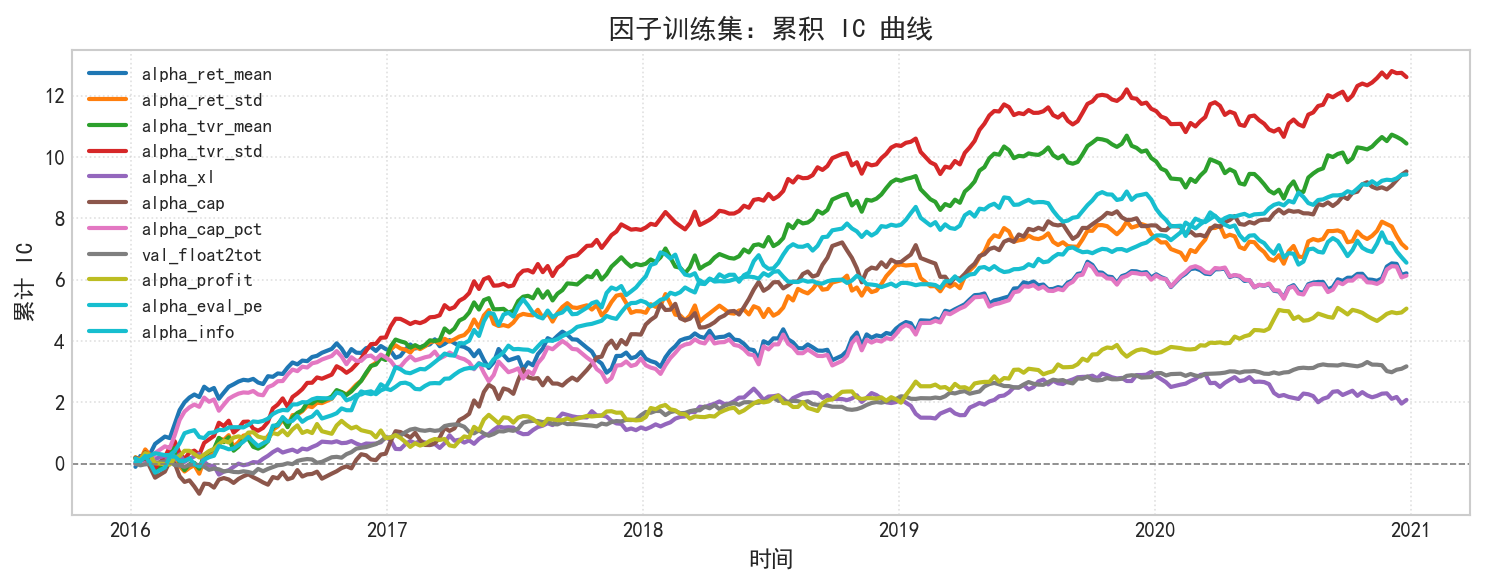

,IC,IR,tvr
alpha_tvr_std,0.049634,0.263001,24.57%
alpha_tvr_mean,0.041103,0.202922,21.86%
alpha_cap,0.037525,0.200930,4.45%
alpha_info,0.037136,0.369496,55.14%
alpha_ret_std,0.027670,0.135097,34.65%
alpha_eval_pe,0.025805,0.136041,5.06%
alpha_cap_pct,0.024524,0.139130,67.06%
alpha_ret_mean,0.024439,0.136830,66.85%
alpha_profit,0.019909,0.161890,4.77%
val_float2tot,0.012493,0.205314,1.76%


In [4]:
def calc_ic_series(weekly_df, factor_cols, method='spearman', min_obs=30):
    ic_dict = {}
    for f in factor_cols:
        def calc_one_date(x, fac=f):
            tmp = x[[f, 'next_ret']].dropna()
            if len(tmp) < min_obs:
                return np.nan
            return tmp[f].corr(tmp['next_ret'], method=method)

        ic_s = weekly_df.groupby('time').apply(calc_one_date)
        ic_dict[f] = ic_s
    ic_df = pd.DataFrame(ic_dict).sort_index()
    ic_df.index.name = 'time'
    return ic_df

ic_df = calc_ic_series(train_weekly, all_factors, method='spearman', min_obs=20)
cum_ic_df = ic_df.cumsum()

plt.figure(figsize=(10, 4), dpi=150)
cmap = plt.get_cmap('tab10')

cum_ic_plot = cum_ic_df.ffill().fillna(0)
for i, f in enumerate(all_factors):
    plt.plot(cum_ic_plot.index, cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=0.8)
plt.title('因子训练集：累积 IC 曲线', fontsize=13)
plt.xlabel('时间', fontsize=11)
plt.ylabel('累计 IC', fontsize=11)
plt.tick_params(labelsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

# tvr
def calc_tvr_zscore(df, factors):
    df_z = df.copy()
    for f in factors:
        df_z[f] = df_z.groupby('time')[f].transform(
            lambda x: (x - x.mean()) / x.std()
        )
    diffs = df_z.groupby('code')[factors].diff().abs()
    tvr_t = diffs.groupby(df_z['time']).sum() / df_z[factors].abs().groupby(df_z['time']).sum().replace(0, np.nan)
    return tvr_t.mean()

IC = ic_df.mean()
IR = ic_df.mean()/ic_df.std()
tvr = calc_tvr_zscore(train_weekly, all_factors)
tvr_fmt = (tvr * 100).round(2).astype(str) + '%'

summary = pd.DataFrame({
    'IC': IC,
    'IR': IR,
    'tvr': tvr_fmt,
}).sort_values('IC', ascending=False)
display(summary)

### 1.5 因子测试集

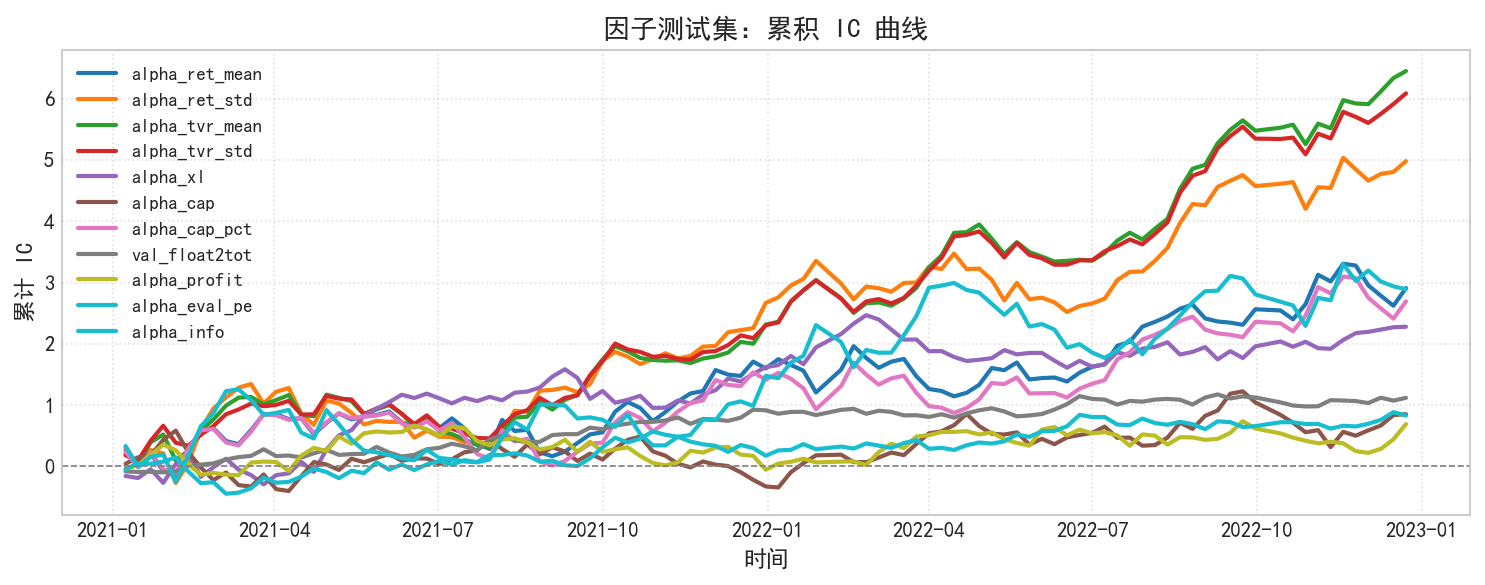

,IC,IR,tvr
alpha_tvr_mean,0.063864,0.343280,22.37%
alpha_tvr_std,0.060257,0.357452,26.14%
alpha_ret_std,0.049329,0.232389,32.75%
alpha_ret_mean,0.028817,0.149402,66.94%
alpha_eval_pe,0.028625,0.124026,4.66%
alpha_cap_pct,0.026671,0.139099,66.72%
alpha_xl,0.022565,0.161902,137.61%
val_float2tot,0.011083,0.183129,1.71%
alpha_cap,0.008445,0.059287,5.35%
alpha_info,0.008241,0.095882,54.41%


In [5]:
# IC
test_ic_df = calc_ic_series(test_weekly, all_factors, method='spearman', min_obs=20)
test_cum_ic_df = test_ic_df.cumsum()
test_cum_ic_plot = test_cum_ic_df.ffill().fillna(0)

plt.figure(figsize=(10, 4), dpi=150)
cmap = plt.get_cmap('tab10')

for i, f in enumerate(all_factors):
    plt.plot(test_cum_ic_plot.index, test_cum_ic_plot[f], label=f, color=cmap(i), linewidth=2)

plt.axhline(0, linestyle='--', color='gray', linewidth=0.8)
plt.title('因子测试集：累积 IC 曲线', fontsize=13)
plt.xlabel('时间', fontsize=11)
plt.ylabel('累计 IC', fontsize=11)
plt.tick_params(labelsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

IC = test_ic_df.mean()
IR = test_ic_df.mean()/test_ic_df.std()
tvr = calc_tvr_zscore(test_weekly, all_factors)
tvr_fmt = (tvr * 100).round(2).astype(str) + '%'

summary = pd.DataFrame({
    'IC': IC,
    'IR': IR,
    'tvr': tvr_fmt,
}).sort_values('IC', ascending=False)
display(summary)

### 1.6 互信息筛选适合树模型的输入特征值

因子互信息计算结果：


,因子,互信息(MI)
0,alpha_tvr_std,0.001172
1,alpha_tvr_mean,0.000760
2,alpha_cap,0.000510
3,alpha_info,0.000343
4,alpha_eval_pe,0.000305
5,alpha_cap_pct,0.000305
6,alpha_ret_mean,0.000267
7,alpha_profit,0.000241
8,alpha_ret_std,0.000232
9,val_float2tot,0.000202


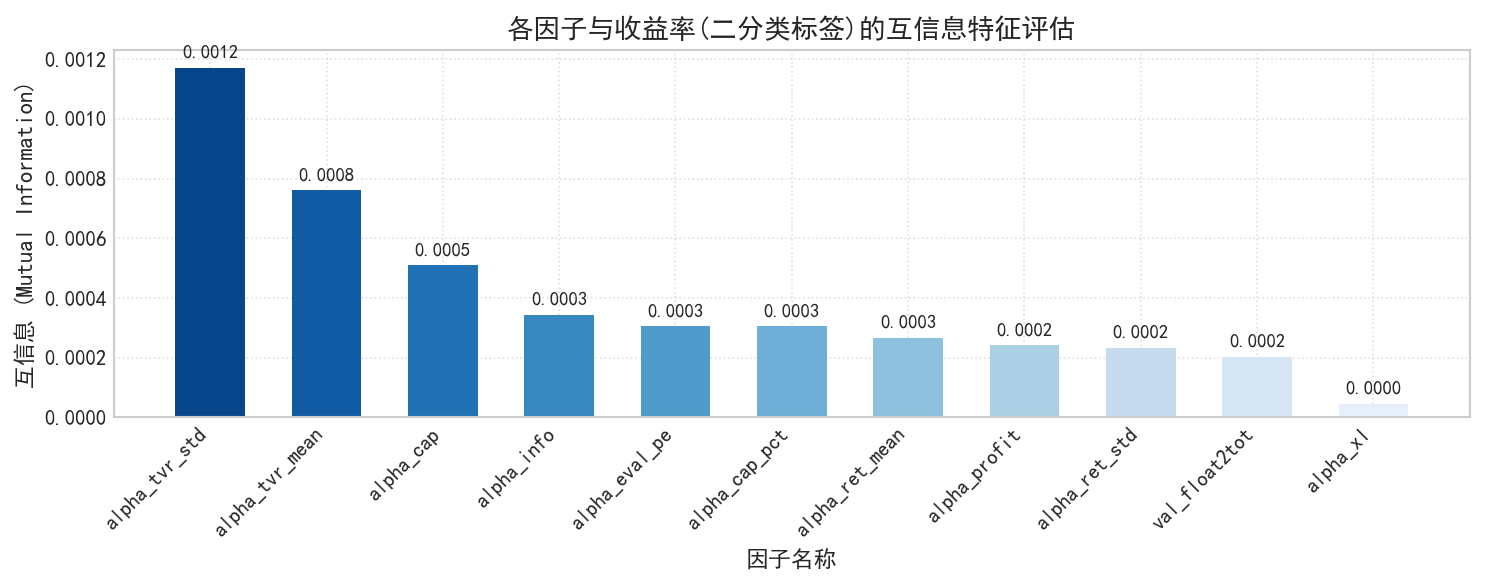

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_mi = ml_train_weekly.copy()
df_mi['label'] = df_mi.groupby('time')['next_ret'].transform(
    lambda x: (x > x.median()).astype(int)
)

# 计算互信息
def calc_discrete_mi(x, y, bins=10):
    valid = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(valid) == 0:
        return np.nan
    # 将连续因子变量离散化
    x_binned = pd.qcut(valid['x'], q=bins, labels=False, duplicates='drop')
    valid['x_bin'] = x_binned
    total = len(valid)

    p_x = valid.groupby('x_bin').size() / total
    p_y = valid.groupby('y').size() / total
    p_xy = valid.groupby(['x_bin', 'y']).size() / total

    mi = 0.0
    for (i, j), p_val in p_xy.items():
        if p_val > 0:
            px_val = p_x[i]
            py_val = p_y[j]
            mi += p_val * np.log(p_val / (px_val * py_val))
    return mi

mi_records = []
for f in all_factors:
    mi_val = calc_discrete_mi(df_mi[f], df_mi['label'], bins=10)
    mi_records.append({'因子': f, '互信息(MI)': mi_val})
mi_df = pd.DataFrame(mi_records).sort_values(by='互信息(MI)', ascending=False).reset_index(drop=True)
print("因子互信息计算结果：")
display(mi_df)

# 画图
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
colors = sns.color_palette("Blues_r", n_colors=len(mi_df))
bars = ax.bar(mi_df['因子'], mi_df['互信息(MI)'], color=colors, width=0.6)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
ax.set_title('各因子与收益率(二分类标签)的互信息特征评估', fontsize=13)
ax.set_xlabel('因子名称', fontsize=11)
ax.set_ylabel('互信息 (Mutual Information)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
ax.grid(linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [7]:
# 除去不要的因子
remove_list = ['alpha_xl']
selected_factors = [f for f in all_factors if f not in remove_list]

print(f"已剔除 {remove_list}")
print(f"剩余参与机器学习的特征数：{len(selected_factors)}")
print(selected_factors)

已剔除 ['alpha_xl']
剩余参与机器学习的特征数：10
['alpha_ret_mean', 'alpha_ret_std', 'alpha_tvr_mean', 'alpha_tvr_std', 'alpha_cap', 'alpha_cap_pct', 'val_float2tot', 'alpha_profit', 'alpha_eval_pe', 'alpha_info']


### 1.7 因子相关性热力图

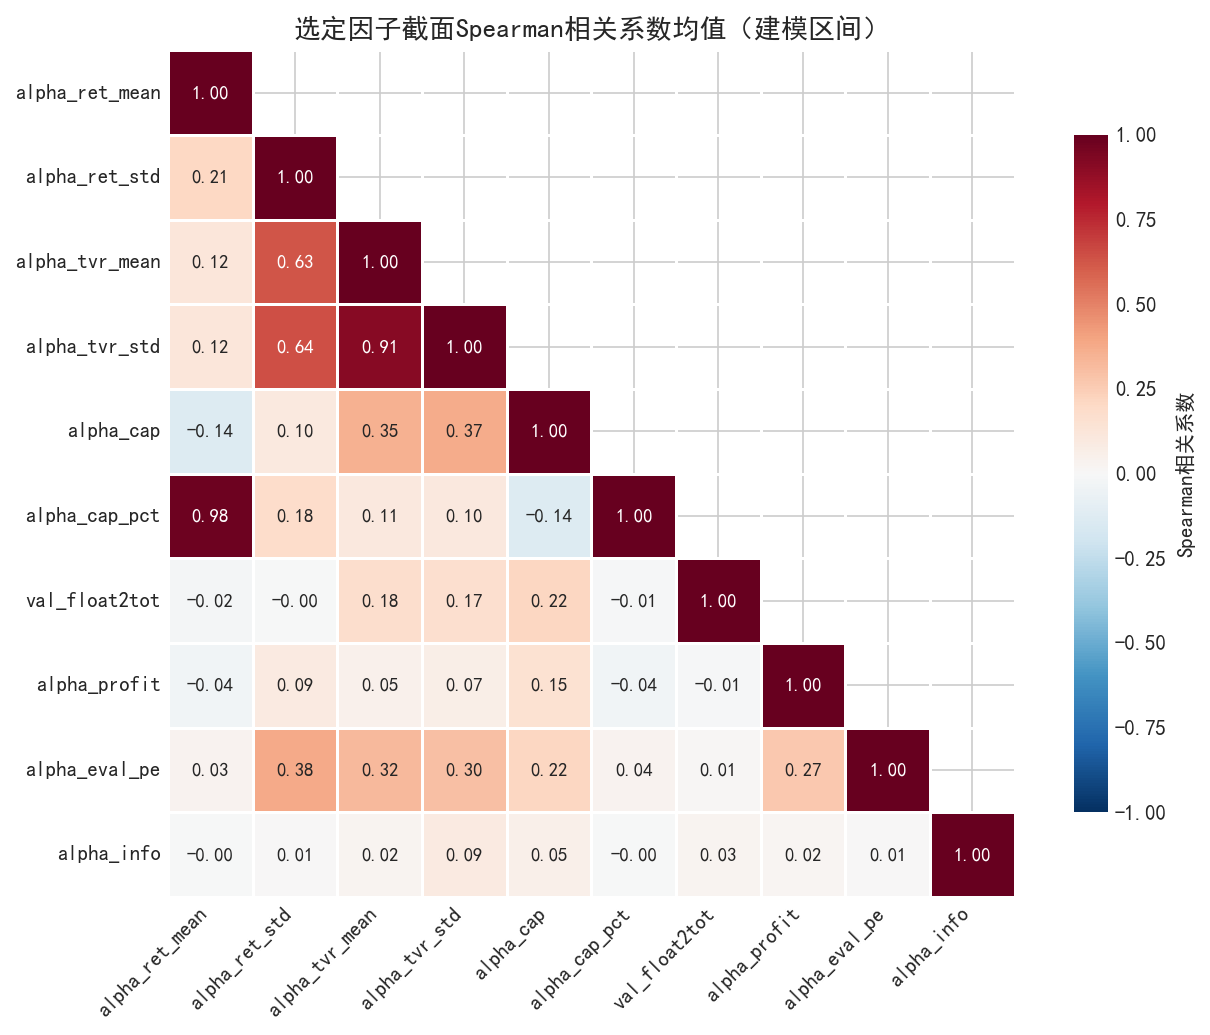

高相关因子对（|corr| > 0.5）：
  alpha_ret_mean vs alpha_cap_pct: 0.983
  alpha_ret_std vs alpha_tvr_mean: 0.631
  alpha_ret_std vs alpha_tvr_std: 0.642
  alpha_tvr_mean vs alpha_tvr_std: 0.914


In [8]:
# 截面相关性热力图
import seaborn as sns

corr_by_date = []
for t, grp in ml_train_weekly.groupby('time'):
    sub = grp[selected_factors].dropna()
    if len(sub) > 20:
        corr_by_date.append(sub.corr(method='spearman'))

avg_corr = pd.concat(corr_by_date).groupby(level=0).mean()
avg_corr = avg_corr.reindex(index=selected_factors, columns=selected_factors)

fig, ax = plt.subplots(figsize=(9, 7), dpi=150)
mask = np.triu(np.ones_like(avg_corr, dtype=bool), k=1)
sns.heatmap(avg_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Spearman相关系数'},
            annot_kws={'fontsize': 9}, ax=ax)
ax.set_title('选定因子截面Spearman相关系数均值（建模区间）', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

print("高相关因子对（|corr| > 0.5）：")
for i in range(len(selected_factors)):
    for j in range(i+1, len(selected_factors)):
        c = avg_corr.iloc[i, j]
        if abs(c) > 0.5:
            print(f"  {selected_factors[i]} vs {selected_factors[j]}: {c:.3f}")

## 2. 梯度提升树stacking集成预测

### 2.1 建模区间：滚动训练

尝试了如下的滚动方式，最终选择建模区间f1-score和report整体最佳的一种：

- 6个月-3个月-3个月
- 一年半-5个月-5个月：最佳（80周-20周-20周）
- 两年-半年-半年
- 三年-半年-半年
- 四年-半年-半年
- 五年-一年-半年（研报）

超参数设定：

| 超参数 | 搜索范围 | 说明 |
|--------|---------|------|
| max_depth | {3, 4, 5} | 树的最大深度，控制模型复杂度 |
| learning_rate | {0.05, 0.1} | 学习率 |
| n_estimators | {50, 100} | 基学习器数量 |
| cv (Stacking) | 3 | Stacking内部交叉验证折数 |
| 元学习器 | LogisticRegression (默认参数) | L2正则化，C=1.0 |

共12组超参组合，每个滚动窗口在验证集上选择准确率最高的组合。

In [10]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import pandas as pd

# 在建模区间上进行滚动预测分析
filtered_df = ml_train_df.copy()
full_weekly = resample_to_weekly(filtered_df, all_factors)
full_weekly = full_weekly.sort_values(['time', 'code']).reset_index(drop=True)

# 标签：下一期收益率是否大于截面中位数
full_weekly['label'] = full_weekly.groupby('time')['next_ret'].transform(
    lambda x: (x > x.median()).astype(int)
)
all_dates = sorted(full_weekly['time'].dropna().unique())
print(f"总调仓周数: {len(all_dates)}")


TRAIN_W = 80
VAL_W = 20
TEST_W = 20
STEP = 20
predictions = []
fi_records = []
xgb_fi_records = []
accuracy_records = []
start_idx = 0

# 超参组合
param_grid = [
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 50},
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 50},
    {'max_depth': 4, 'learning_rate': 0.1,  'n_estimators': 100},
    {'max_depth': 5, 'learning_rate': 0.1,  'n_estimators': 100}
]

print("开始滚动训练")

while start_idx + TRAIN_W + VAL_W < len(all_dates):
    end_idx = min(start_idx + TRAIN_W + VAL_W + TEST_W, len(all_dates))
    
    fit_dates  = all_dates[start_idx : start_idx + TRAIN_W]
    val_dates  = all_dates[start_idx + TRAIN_W : start_idx + TRAIN_W + VAL_W]
    test_dates = all_dates[start_idx + TRAIN_W + VAL_W : end_idx]
    
    if len(test_dates) == 0: break
        
    fit_data  = full_weekly[full_weekly['time'].isin(fit_dates)]
    val_data  = full_weekly[full_weekly['time'].isin(val_dates)]
    test_data = full_weekly[full_weekly['time'].isin(test_dates)]
    
    if len(fit_data) < 200 or len(test_data) == 0:
        start_idx += STEP
        continue

    X_fit = fit_data[selected_factors].fillna(0).values
    y_fit = fit_data['label'].values
    X_val = val_data[selected_factors].fillna(0).values
    y_val = val_data['label'].values
    X_test = test_data[selected_factors].fillna(0).values
    y_test = test_data['label'].values
    
    # 动态超参数网格寻优
    best_val_acc = -np.inf
    best_params = param_grid[0]
    
    for params in param_grid:
        tmp_model = lgb.LGBMClassifier(
            n_estimators=params['n_estimators'], 
            max_depth=params['max_depth'], 
            learning_rate=params['learning_rate'],
            random_state=42, verbose=-1, n_jobs=-1
        )
        tmp_model.fit(X_fit, y_fit)
        val_pred = tmp_model.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = params
            
    # 使用最佳超参在验证集表现最好的模型
    xgb_clf = xgb.XGBClassifier(
        n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], 
        learning_rate=best_params['learning_rate'], random_state=42, n_jobs=-1, verbosity=0
    )
    
    lgb_clf = lgb.LGBMClassifier(
        n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], 
        learning_rate=best_params['learning_rate'], random_state=42, n_jobs=-1, verbose=-1
    )
    
    # 定义Stacking模型
    stack_clf = StackingClassifier(
        estimators=[('xgb', xgb_clf), ('lgb', lgb_clf)],
        final_estimator=LogisticRegression(),
        cv=3,
        n_jobs=-1
    )
    
    stack_clf.fit(X_fit, y_fit)
    fitted_xgb = stack_clf.estimators_[0]
    fitted_lgb = stack_clf.estimators_[1]
    
    stack_pred = stack_clf.predict(X_test)
    stack_proba = stack_clf.predict_proba(X_test)[:, 1]
    
    train_acc = stack_clf.score(X_fit, y_fit)
    val_acc = stack_clf.score(X_val, y_val)
    test_acc = accuracy_score(y_test, stack_pred)
    test_f1 = f1_score(y_test, stack_pred, average='macro')
    
    pred_df = test_data[['time', 'code', 'next_ret', 'label']].copy()
    pred_df['pred_class'] = stack_pred
    pred_df['stacking_score'] = stack_proba
    predictions.append(pred_df)
    
    accuracy_records.append({
        'Window': f"{start_idx}-{end_idx}",
        'Test_Start': test_dates[0].date(),
        'Train_Acc': round(train_acc, 4),
        'Val_Acc': round(val_acc, 4),
        'Test_Acc': round(test_acc, 4),
        'Test_F1': round(test_f1, 4),
        'Best_Depth': best_params['max_depth'],
        'Best_LR': best_params['learning_rate'],
        'Best_N': best_params['n_estimators'],
    })
    
    fi = dict(zip(selected_factors, fitted_lgb.feature_importances_))
    fi_records.append(fi)
    fi_xgb = dict(zip(selected_factors, fitted_xgb.feature_importances_))
    xgb_fi_records.append(fi_xgb)
    
    print(f"窗口 {test_dates[0].date()} | 调优选中: Depth={best_params['max_depth']}, n={best_params['n_estimators']} | "
          f"Train Acc:{train_acc:.3f} Val Acc:{val_acc:.3f} Test Acc:{test_acc:.3f} Test F1:{test_f1:.3f}")
    
    start_idx += STEP

pred_all = pd.concat(predictions, ignore_index=True)
fi_df = pd.DataFrame(fi_records)
xgb_fi_df = pd.DataFrame(xgb_fi_records)
acc_df = pd.DataFrame(accuracy_records)

print("分类评估报告")
print(classification_report(pred_all['label'], pred_all['pred_class']))
display(acc_df)

总调仓周数: 356
开始滚动训练
窗口 2017-12-29 | 调优选中: Depth=5, n=100 | Train Acc:0.643 Val Acc:0.527 Test Acc:0.517 Test F1:0.515
窗口 2018-05-18 | 调优选中: Depth=4, n=50 | Train Acc:0.573 Val Acc:0.516 Test Acc:0.518 Test F1:0.496
窗口 2018-10-12 | 调优选中: Depth=4, n=50 | Train Acc:0.574 Val Acc:0.521 Test Acc:0.491 Test F1:0.482
窗口 2019-03-08 | 调优选中: Depth=4, n=100 | Train Acc:0.597 Val Acc:0.491 Test Acc:0.510 Test F1:0.508
窗口 2019-07-26 | 调优选中: Depth=3, n=50 | Train Acc:0.548 Val Acc:0.505 Test Acc:0.513 Test F1:0.486
窗口 2019-12-13 | 调优选中: Depth=4, n=100 | Train Acc:0.605 Val Acc:0.520 Test Acc:0.499 Test F1:0.479
窗口 2020-05-08 | 调优选中: Depth=3, n=50 | Train Acc:0.548 Val Acc:0.506 Test Acc:0.517 Test F1:0.491
窗口 2020-09-25 | 调优选中: Depth=3, n=50 | Train Acc:0.552 Val Acc:0.522 Test Acc:0.522 Test F1:0.519
窗口 2021-02-12 | 调优选中: Depth=3, n=50 | Train Acc:0.554 Val Acc:0.528 Test Acc:0.502 Test F1:0.498
窗口 2021-07-02 | 调优选中: Depth=5, n=100 | Train Acc:0.672 Val Acc:0.500 Test Acc:0.518 Test F1:0.516
窗口 2021-

,Window,Test_Start,Train_Acc,Val_Acc,Test_Acc,Test_F1,Best_Depth,Best_LR,Best_N
0,0-120,2017-12-29,0.6429,0.5267,0.5174,0.5152,5,0.10,100
1,20-140,2018-05-18,0.5730,0.5162,0.5179,0.4959,4,0.05,50
2,40-160,2018-10-12,0.5741,0.5212,0.4905,0.4817,4,0.05,50
3,60-180,2019-03-08,0.5973,0.4905,0.5099,0.5083,4,0.10,100
4,80-200,2019-07-26,0.5482,0.5052,0.5130,0.4860,3,0.05,50
5,100-220,2019-12-13,0.6046,0.5200,0.4988,0.4788,4,0.10,100
6,120-240,2020-05-08,0.5475,0.5059,0.5168,0.4907,3,0.05,50
7,140-260,2020-09-25,0.5521,0.5218,0.5217,0.5188,3,0.05,50
8,160-280,2021-02-12,0.5543,0.5284,0.5025,0.4976,3,0.05,50
9,180-300,2021-07-02,0.6720,0.4997,0.5183,0.5164,5,0.10,100


### 2.2 回测区间：滚动训练

In [9]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import pandas as pd

# 应用到全区间
filtered_df = df.copy()
full_weekly = resample_to_weekly(filtered_df, all_factors)
full_weekly = full_weekly.sort_values(['time', 'code']).reset_index(drop=True)

full_weekly['label'] = full_weekly.groupby('time')['next_ret'].transform(
    lambda x: (x > x.median()).astype(int)
)
all_dates = sorted(full_weekly['time'].dropna().unique())
print(f"总调仓周数: {len(all_dates)}")


TRAIN_W = 80
VAL_W = 20
TEST_W = 20
STEP = 20
predictions = []
fi_records = []
xgb_fi_records = []
accuracy_records = []
start_idx = 0

# 超参组合
param_grid = [
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 50},
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 50},
    {'max_depth': 4, 'learning_rate': 0.1,  'n_estimators': 100},
    {'max_depth': 5, 'learning_rate': 0.1,  'n_estimators': 100}
]

print("开始滚动训练")

while start_idx + TRAIN_W + VAL_W < len(all_dates):
    end_idx = min(start_idx + TRAIN_W + VAL_W + TEST_W, len(all_dates))
    
    fit_dates  = all_dates[start_idx : start_idx + TRAIN_W]
    val_dates  = all_dates[start_idx + TRAIN_W : start_idx + TRAIN_W + VAL_W]
    test_dates = all_dates[start_idx + TRAIN_W + VAL_W : end_idx]
    
    if len(test_dates) == 0: break
        
    fit_data  = full_weekly[full_weekly['time'].isin(fit_dates)]
    val_data  = full_weekly[full_weekly['time'].isin(val_dates)]
    test_data = full_weekly[full_weekly['time'].isin(test_dates)]
    
    if len(fit_data) < 200 or len(test_data) == 0:
        start_idx += STEP
        continue

    X_fit = fit_data[selected_factors].fillna(0).values
    y_fit = fit_data['label'].values
    X_val = val_data[selected_factors].fillna(0).values
    y_val = val_data['label'].values
    X_test = test_data[selected_factors].fillna(0).values
    y_test = test_data['label'].values
    
    # 动态超参数网格寻优
    best_val_acc = -np.inf
    best_params = param_grid[0]
    
    for params in param_grid:
        tmp_model = lgb.LGBMClassifier(
            n_estimators=params['n_estimators'], 
            max_depth=params['max_depth'], 
            learning_rate=params['learning_rate'],
            random_state=42, verbose=-1, n_jobs=-1
        )
        tmp_model.fit(X_fit, y_fit)
        val_pred = tmp_model.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = params
            
    # 使用最佳超参在验证集表现最好的模型
    xgb_clf = xgb.XGBClassifier(
        n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], 
        learning_rate=best_params['learning_rate'], random_state=42, n_jobs=-1, verbosity=0
    )
    
    lgb_clf = lgb.LGBMClassifier(
        n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], 
        learning_rate=best_params['learning_rate'], random_state=42, n_jobs=-1, verbose=-1
    )
    
    # 定义Stacking模型
    stack_clf = StackingClassifier(
        estimators=[('xgb', xgb_clf), ('lgb', lgb_clf)],
        final_estimator=LogisticRegression(),
        cv=3,
        n_jobs=-1
    )
    
    stack_clf.fit(X_fit, y_fit)
    fitted_xgb = stack_clf.estimators_[0]
    fitted_lgb = stack_clf.estimators_[1]
    
    stack_pred = stack_clf.predict(X_test)
    stack_proba = stack_clf.predict_proba(X_test)[:, 1]
    
    train_acc = stack_clf.score(X_fit, y_fit)
    val_acc = stack_clf.score(X_val, y_val)
    test_acc = accuracy_score(y_test, stack_pred)
    test_f1 = f1_score(y_test, stack_pred, average='macro')
    
    pred_df = test_data[['time', 'code', 'next_ret', 'label']].copy()
    pred_df['pred_class'] = stack_pred
    pred_df['stacking_score'] = stack_proba
    predictions.append(pred_df)
    
    accuracy_records.append({
        'Window': f"{start_idx}-{end_idx}",
        'Test_Start': test_dates[0].date(),
        'Train_Acc': round(train_acc, 4),
        'Val_Acc': round(val_acc, 4),
        'Test_Acc': round(test_acc, 4),
        'Test_F1': round(test_f1, 4),
        'Best_Depth': best_params['max_depth'],
        'Best_LR': best_params['learning_rate'],
        'Best_N': best_params['n_estimators'],
    })
    
    fi = dict(zip(selected_factors, fitted_lgb.feature_importances_))
    fi_records.append(fi)
    fi_xgb = dict(zip(selected_factors, fitted_xgb.feature_importances_))
    xgb_fi_records.append(fi_xgb)
    
    print(f"窗口 {test_dates[0].date()} | 调优选中: Depth={best_params['max_depth']}, n={best_params['n_estimators']} | "
          f"Train Acc:{train_acc:.3f} Val Acc:{val_acc:.3f} Test Acc:{test_acc:.3f} Test F1:{test_f1:.3f}")
    
    start_idx += STEP

pred_all = pd.concat(predictions, ignore_index=True)
fi_df = pd.DataFrame(fi_records)
xgb_fi_df = pd.DataFrame(xgb_fi_records)
acc_df = pd.DataFrame(accuracy_records)

print("分类评估报告")
print(classification_report(pred_all['label'], pred_all['pred_class']))
display(acc_df)

总调仓周数: 513
开始滚动训练
窗口 2017-12-29 | 调优选中: Depth=4, n=50 | Train Acc:0.565 Val Acc:0.524 Test Acc:0.524 Test F1:0.524
窗口 2018-05-18 | 调优选中: Depth=3, n=50 | Train Acc:0.554 Val Acc:0.514 Test Acc:0.521 Test F1:0.496
窗口 2018-10-12 | 调优选中: Depth=4, n=50 | Train Acc:0.575 Val Acc:0.520 Test Acc:0.493 Test F1:0.483
窗口 2019-03-08 | 调优选中: Depth=4, n=100 | Train Acc:0.599 Val Acc:0.488 Test Acc:0.511 Test F1:0.509
窗口 2019-07-26 | 调优选中: Depth=4, n=50 | Train Acc:0.563 Val Acc:0.510 Test Acc:0.515 Test F1:0.494
窗口 2019-12-13 | 调优选中: Depth=4, n=50 | Train Acc:0.563 Val Acc:0.514 Test Acc:0.491 Test F1:0.479
窗口 2020-05-08 | 调优选中: Depth=3, n=50 | Train Acc:0.544 Val Acc:0.505 Test Acc:0.518 Test F1:0.492
窗口 2020-09-25 | 调优选中: Depth=3, n=50 | Train Acc:0.552 Val Acc:0.520 Test Acc:0.522 Test F1:0.518
窗口 2021-02-12 | 调优选中: Depth=3, n=50 | Train Acc:0.553 Val Acc:0.528 Test Acc:0.505 Test F1:0.500
窗口 2021-07-02 | 调优选中: Depth=4, n=100 | Train Acc:0.623 Val Acc:0.498 Test Acc:0.514 Test F1:0.512
窗口 2021-11

,Window,Test_Start,Train_Acc,Val_Acc,Test_Acc,Test_F1,Best_Depth,Best_LR,Best_N
0,0-120,2017-12-29,0.5649,0.5242,0.5238,0.5236,4,0.05,50
1,20-140,2018-05-18,0.5541,0.5143,0.5211,0.4958,3,0.05,50
2,40-160,2018-10-12,0.5752,0.5202,0.4932,0.4829,4,0.05,50
3,60-180,2019-03-08,0.5992,0.4882,0.5106,0.5094,4,0.10,100
4,80-200,2019-07-26,0.5633,0.5099,0.5152,0.4942,4,0.05,50
5,100-220,2019-12-13,0.5631,0.5143,0.4910,0.4793,4,0.05,50
6,120-240,2020-05-08,0.5438,0.5047,0.5183,0.4922,3,0.05,50
7,140-260,2020-09-25,0.5523,0.5205,0.5216,0.5181,3,0.05,50
8,160-280,2021-02-12,0.5533,0.5283,0.5048,0.5000,3,0.05,50
9,180-300,2021-07-02,0.6235,0.4983,0.5142,0.5123,4,0.10,100


### 2.3 不同置信度分组分析

按模型置信度分组的预测准确率与平均收益率：


,准确率,平均实际收益率,样本数
conf_group,,,
最不看好20%,0.5373,0.0006,9340
次不看好20%,0.5212,0.0008,9357
中间20%,0.4892,0.0018,9367
次看好20%,0.5177,0.0024,9355
最看好20%,0.5494,0.0030,9368


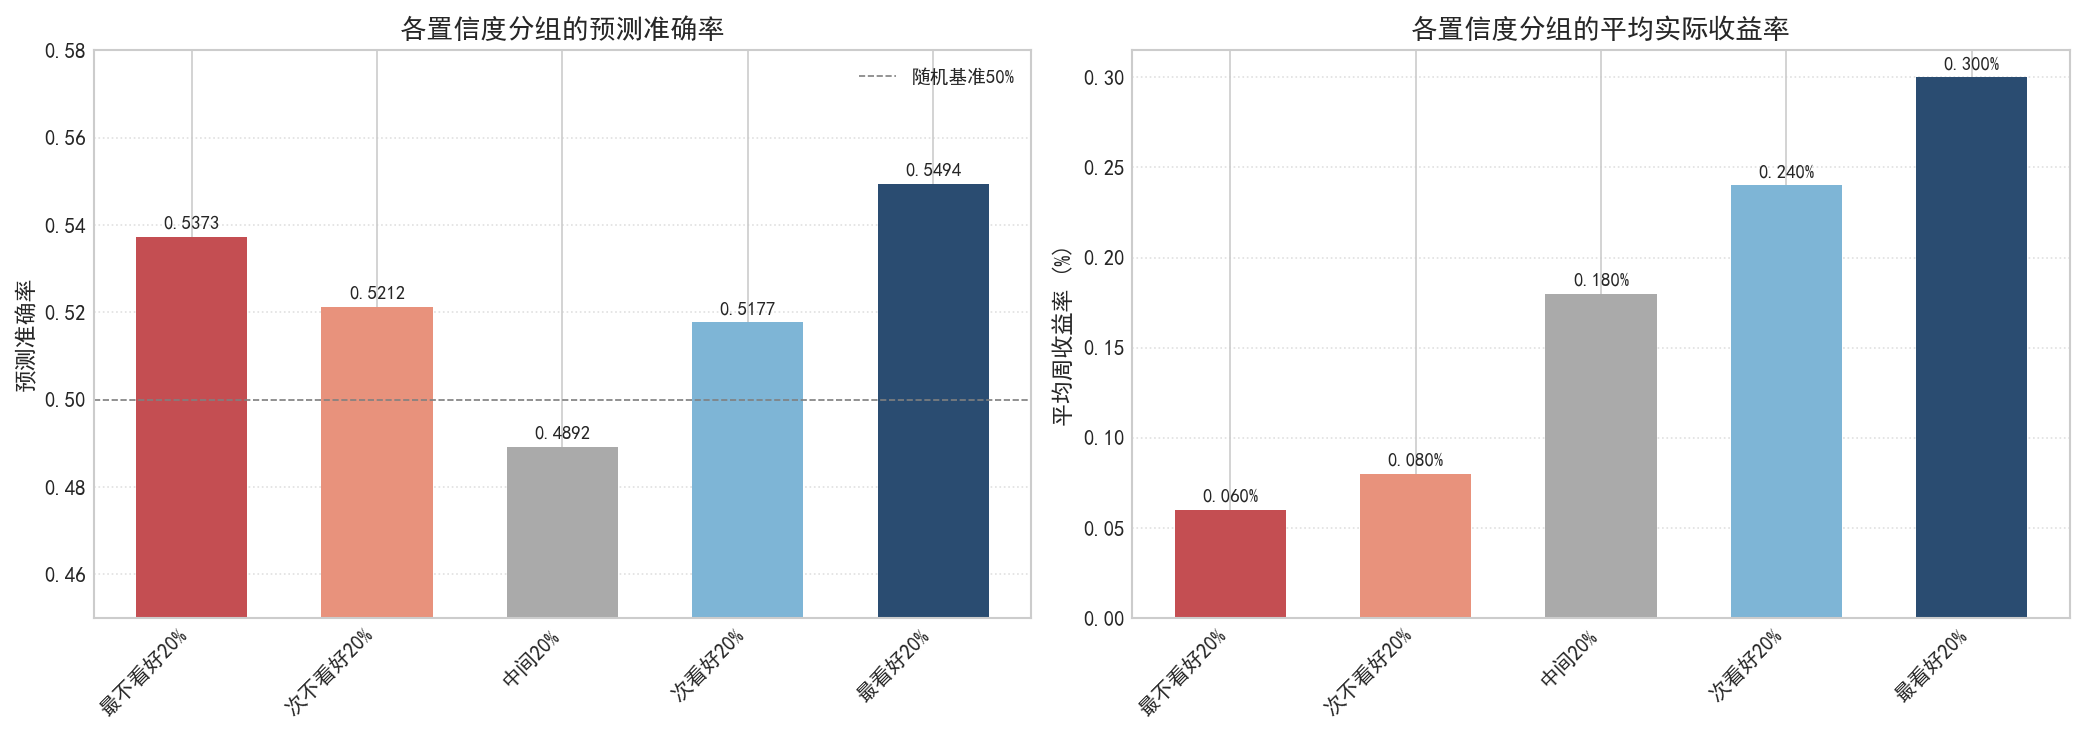

In [10]:
# 按模型置信度分组的预测准确率
pred_test_conf = pred_all[pred_all['time'] >= '2023-01-01'].copy()

# 每期按stacking_score分成5组
def assign_confidence_group(grp):
    grp = grp.copy()
    grp['conf_rank'] = grp['stacking_score'].rank(pct=True)
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labels = ['最不看好20%', '次不看好20%', '中间20%', '次看好20%', '最看好20%']
    grp['conf_group'] = pd.cut(grp['conf_rank'], bins=bins, labels=labels, include_lowest=True)
    return grp

pred_test_conf = pred_test_conf.groupby('time', group_keys=False).apply(assign_confidence_group)
pred_test_conf['correct'] = (pred_test_conf['pred_class'] == pred_test_conf['label']).astype(int)

# 各组准确率
conf_acc = pred_test_conf.groupby('conf_group', observed=True).agg(
    准确率=('correct', 'mean'),
    平均实际收益率=('next_ret', 'mean'),
    样本数=('correct', 'count')
).round(4)

print("按模型置信度分组的预测准确率与平均收益率：")
display(conf_acc)

# 画图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
groups = conf_acc.index.tolist()
colors_bar = ['#C44E52', '#E8927C', '#AAAAAA', '#7EB5D6', '#2A4C71']

bars1 = ax1.bar(groups, conf_acc['准确率'], color=colors_bar, width=0.6)
for bar in bars1:
    h = bar.get_height()
    ax1.annotate(f'{h:.4f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='随机基准50%')
ax1.set_ylabel('预测准确率', fontsize=11)
ax1.set_title('各置信度分组的预测准确率', fontsize=13)
ax1.legend(fontsize=9)
ax1.set_ylim(0.45, 0.58)
ax1.tick_params(labelsize=10)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

bars2 = ax2.bar(groups, conf_acc['平均实际收益率'] * 100, color=colors_bar, width=0.6)
for bar in bars2:
    h = bar.get_height()
    ax2.annotate(f'{h:.3f}%', xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('平均周收益率 (%)', fontsize=11)
ax2.set_title('各置信度分组的平均实际收益率', fontsize=13)
ax2.tick_params(labelsize=10)
ax2.grid(axis='y', linestyle=':', alpha=0.6)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

模型的预测能力集中在两端，由于后续策略仅持有合成因子得分最高的 Top-30 只股票（对应"最看好20%"组），实际利用的正是模型预测能力最强的区域（准确率 54.94%），因此能够实现显著的超额收益。

### 2.4 特征重要性和SHAP分析

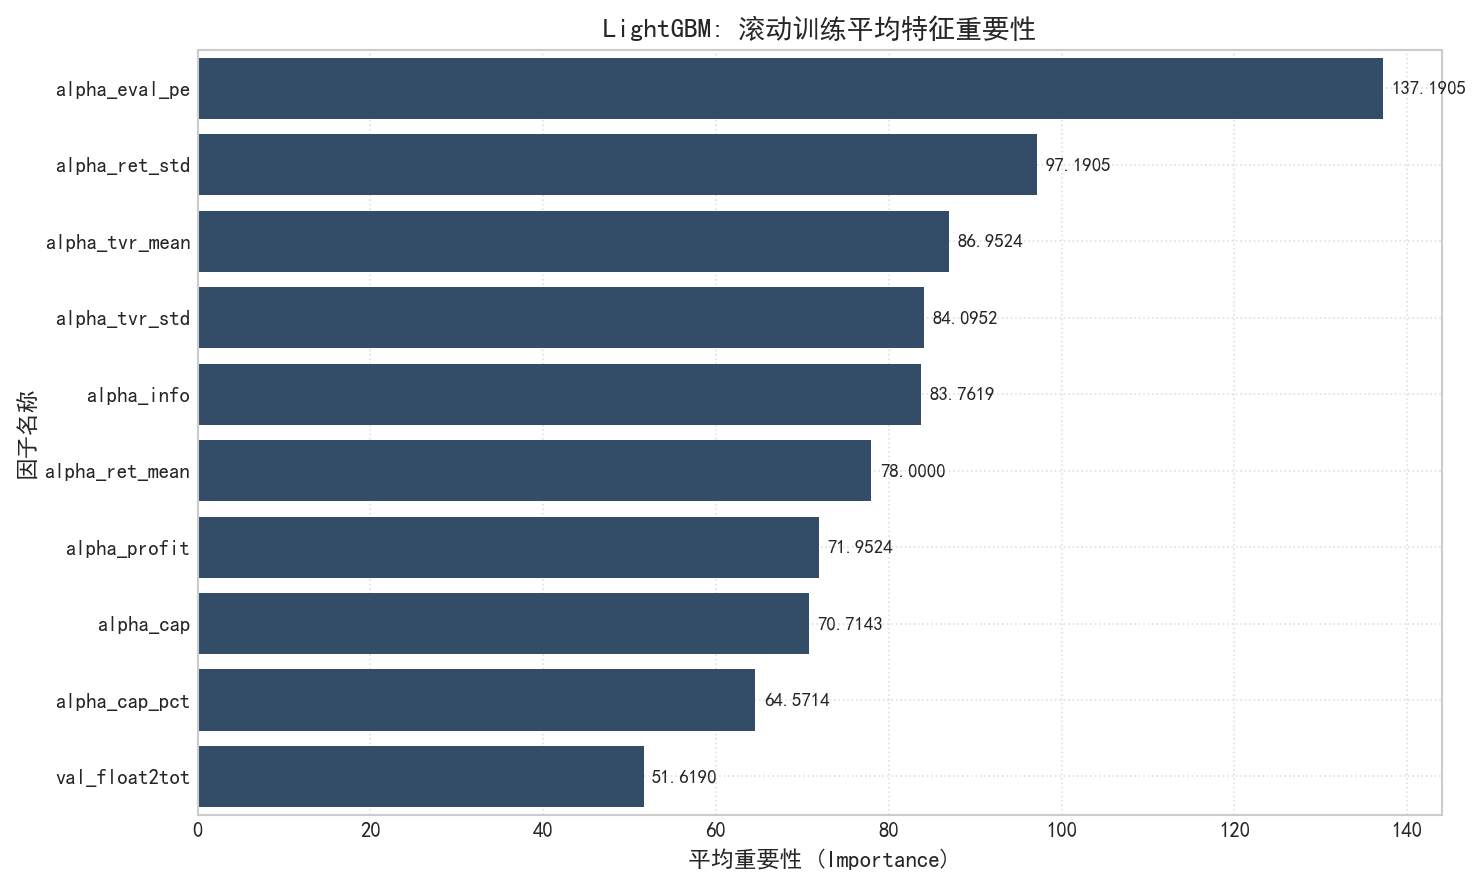

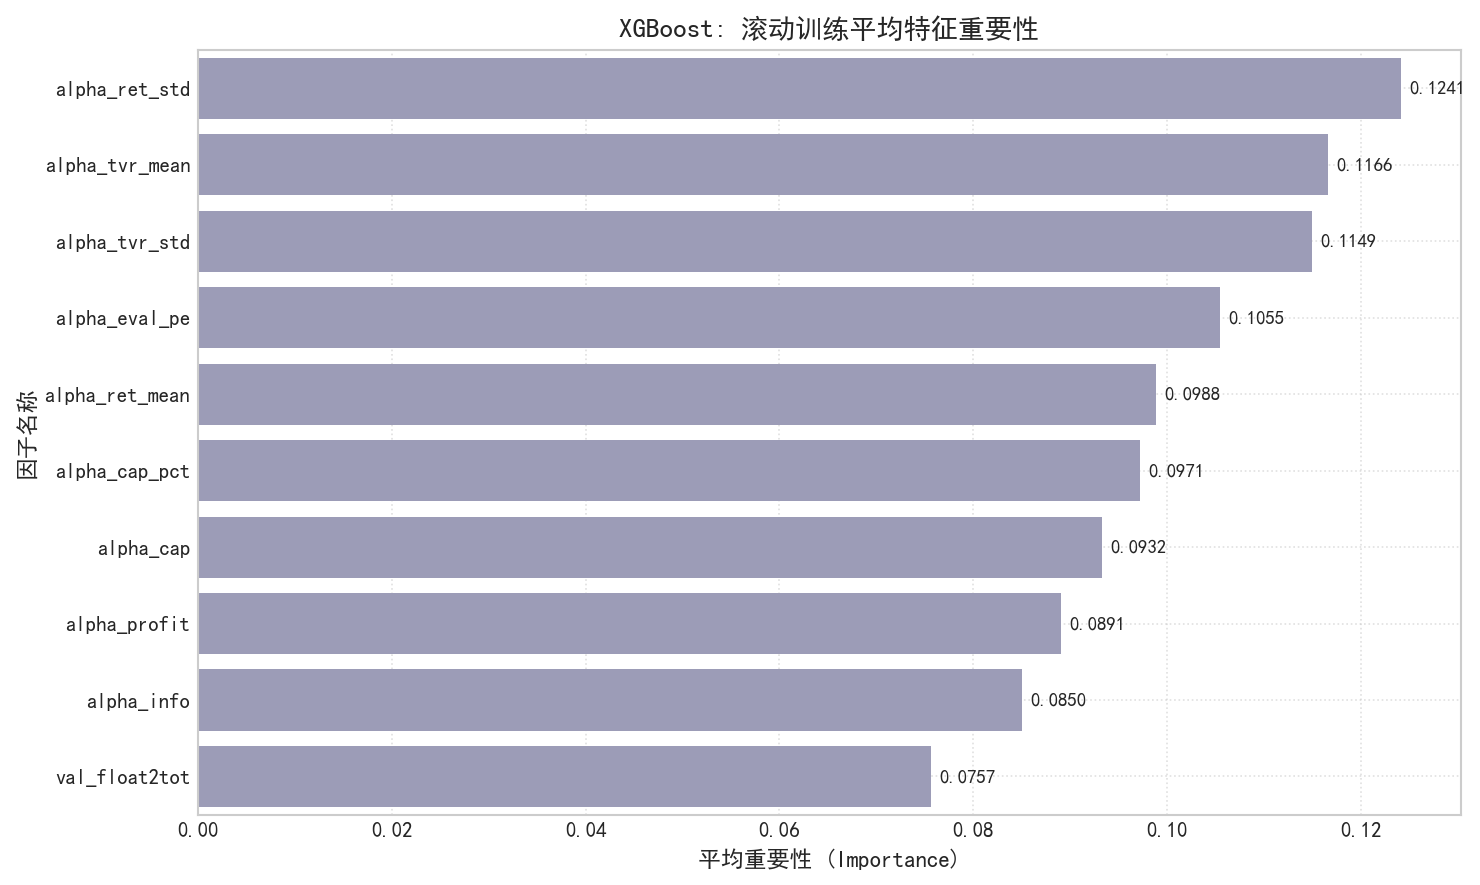

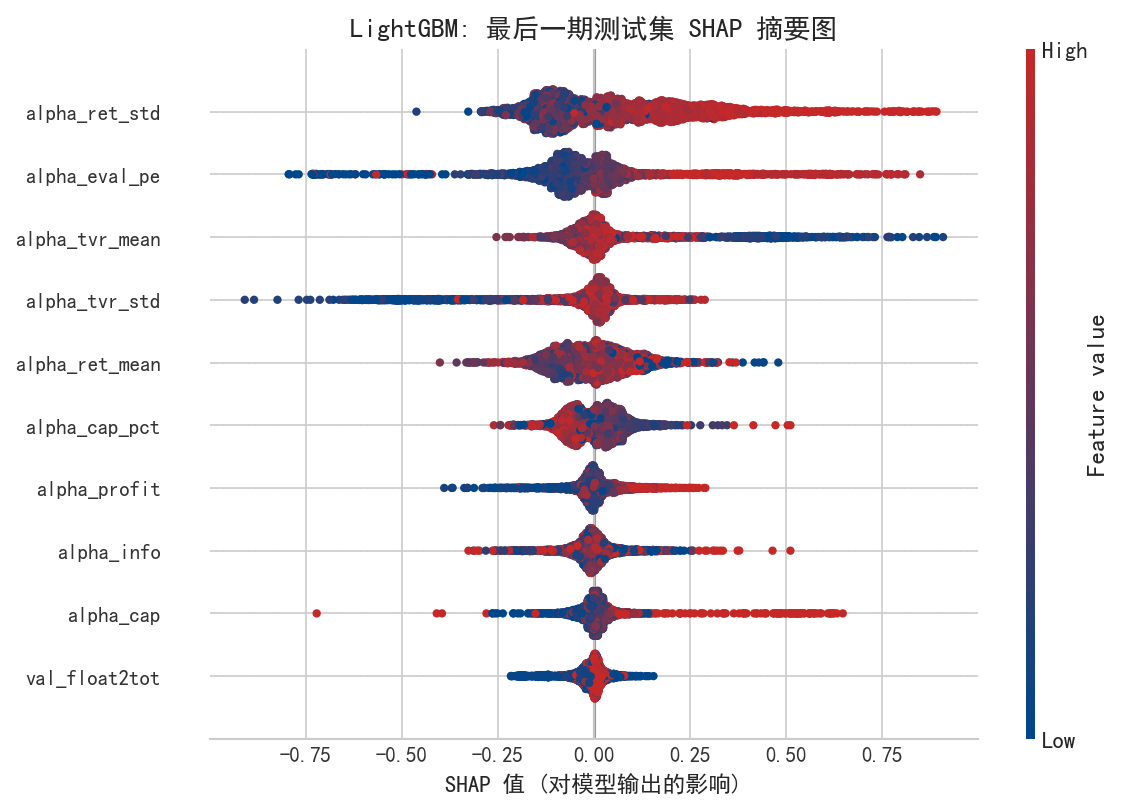

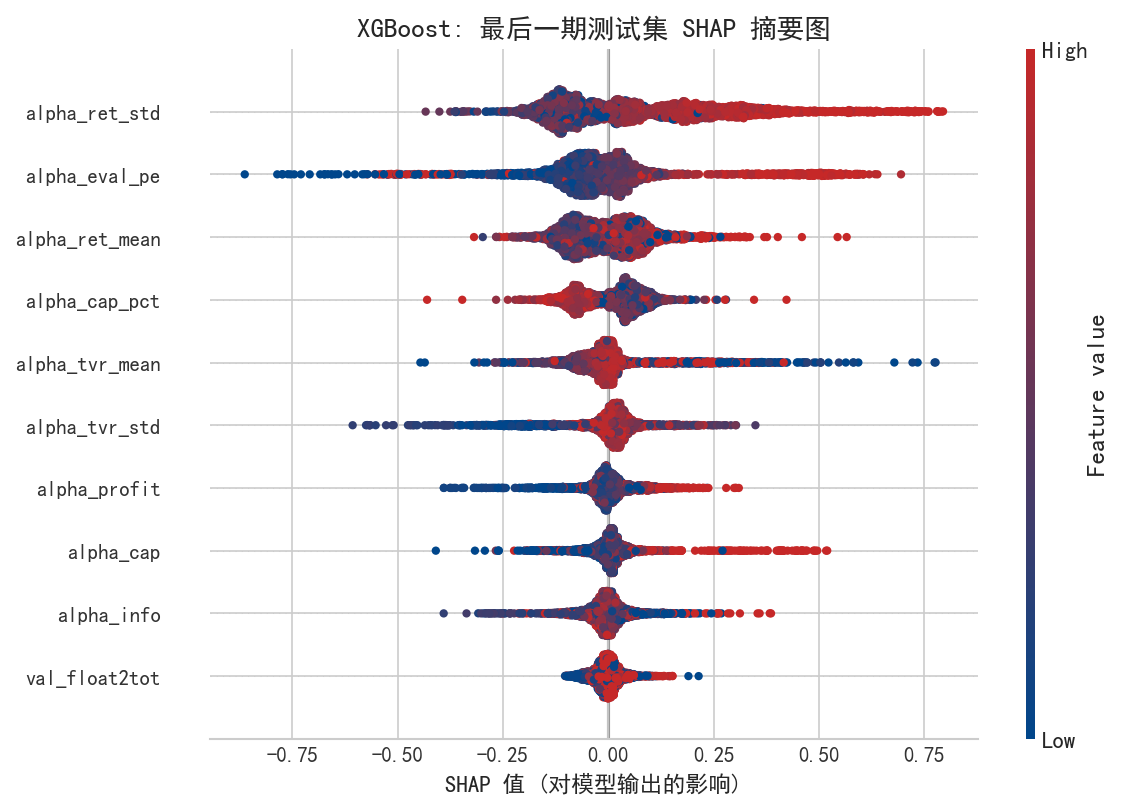

In [11]:
import shap
import seaborn as sns
import matplotlib.pyplot as plt

# 特征重要性
mean_fi_lgb = fi_df.mean().sort_values(ascending=False)
mean_fi_xgb = xgb_fi_df.mean().sort_values(ascending=False)

# LightGBM特征重要性
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(x=mean_fi_lgb.values, y=mean_fi_lgb.index, color='#2A4C71', ax=ax)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.4f}',
                xy=(width, p.get_y() + p.get_height() / 2),
                xytext=(4, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9)
ax.set_title('LightGBM: 滚动训练平均特征重要性', fontsize=13)
ax.set_xlabel('平均重要性 (Importance)', fontsize=11)
ax.set_ylabel('因子名称', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
ax.grid(linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# XGBoost特征重要性
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(x=mean_fi_xgb.values, y=mean_fi_xgb.index, color='#9897BC', ax=ax)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.4f}',
                xy=(width, p.get_y() + p.get_height() / 2),
                xytext=(4, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9)
ax.set_title('XGBoost: 滚动训练平均特征重要性', fontsize=13)
ax.set_xlabel('平均重要性 (Importance)', fontsize=11)
ax.set_ylabel('因子名称', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
ax.grid(linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 最后一个测试集窗口的 SHAP 值摘要图
X_test_df = pd.DataFrame(X_test, columns=selected_factors)

# LightGBM SHAP
explainer_lgb = shap.TreeExplainer(fitted_lgb)
shap_values_lgb = explainer_lgb.shap_values(X_test_df)
if isinstance(shap_values_lgb, list):
    shap_values_lgb_plot = shap_values_lgb[1]
else:
    shap_values_lgb_plot = shap_values_lgb

from matplotlib.colors import LinearSegmentedColormap
fig = plt.figure(figsize=(10, 6), dpi=150)
custom_cmap = LinearSegmentedColormap.from_list('custom_shap', ['#00468B', '#C62828'])
shap.summary_plot(shap_values_lgb_plot, X_test_df, cmap=custom_cmap, show=False)
ax = plt.gca()
ax.set_title('LightGBM: 最后一期测试集 SHAP 摘要图', fontsize=13)
ax.set_xlabel('SHAP 值 (对模型输出的影响)', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# XGBoost SHAP
explainer_xgb = shap.TreeExplainer(fitted_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_df)
if isinstance(shap_values_xgb, list):
    shap_values_xgb_plot = shap_values_xgb[1]
else:
    shap_values_xgb_plot = shap_values_xgb

fig = plt.figure(figsize=(10, 6), dpi=150)
shap.summary_plot(shap_values_xgb_plot, X_test_df, cmap=custom_cmap, show=False)
ax = plt.gca()
ax.set_title('XGBoost: 最后一期测试集 SHAP 摘要图', fontsize=13)
ax.set_xlabel('SHAP 值 (对模型输出的影响)', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 2.5 测试区间：累积IC

测试集 各因子与合成因子 IC 统计对比：


,IC,IR,tvr
Stacking合成因子,0.065819,0.308229,0.559651
等权合成因子,0.053901,0.240208,0.343280
alpha_ret_std,0.053752,0.213792,0.338608
alpha_tvr_std,0.049111,0.202174,0.241037
alpha_tvr_mean,0.048996,0.193522,0.200736
alpha_eval_pe,0.048513,0.205207,0.049142
alpha_cap,0.026165,0.141951,0.047591
alpha_info,0.017656,0.174990,0.554734
alpha_profit,0.017379,0.131817,0.040601
alpha_ret_mean,0.004076,0.019113,0.657556


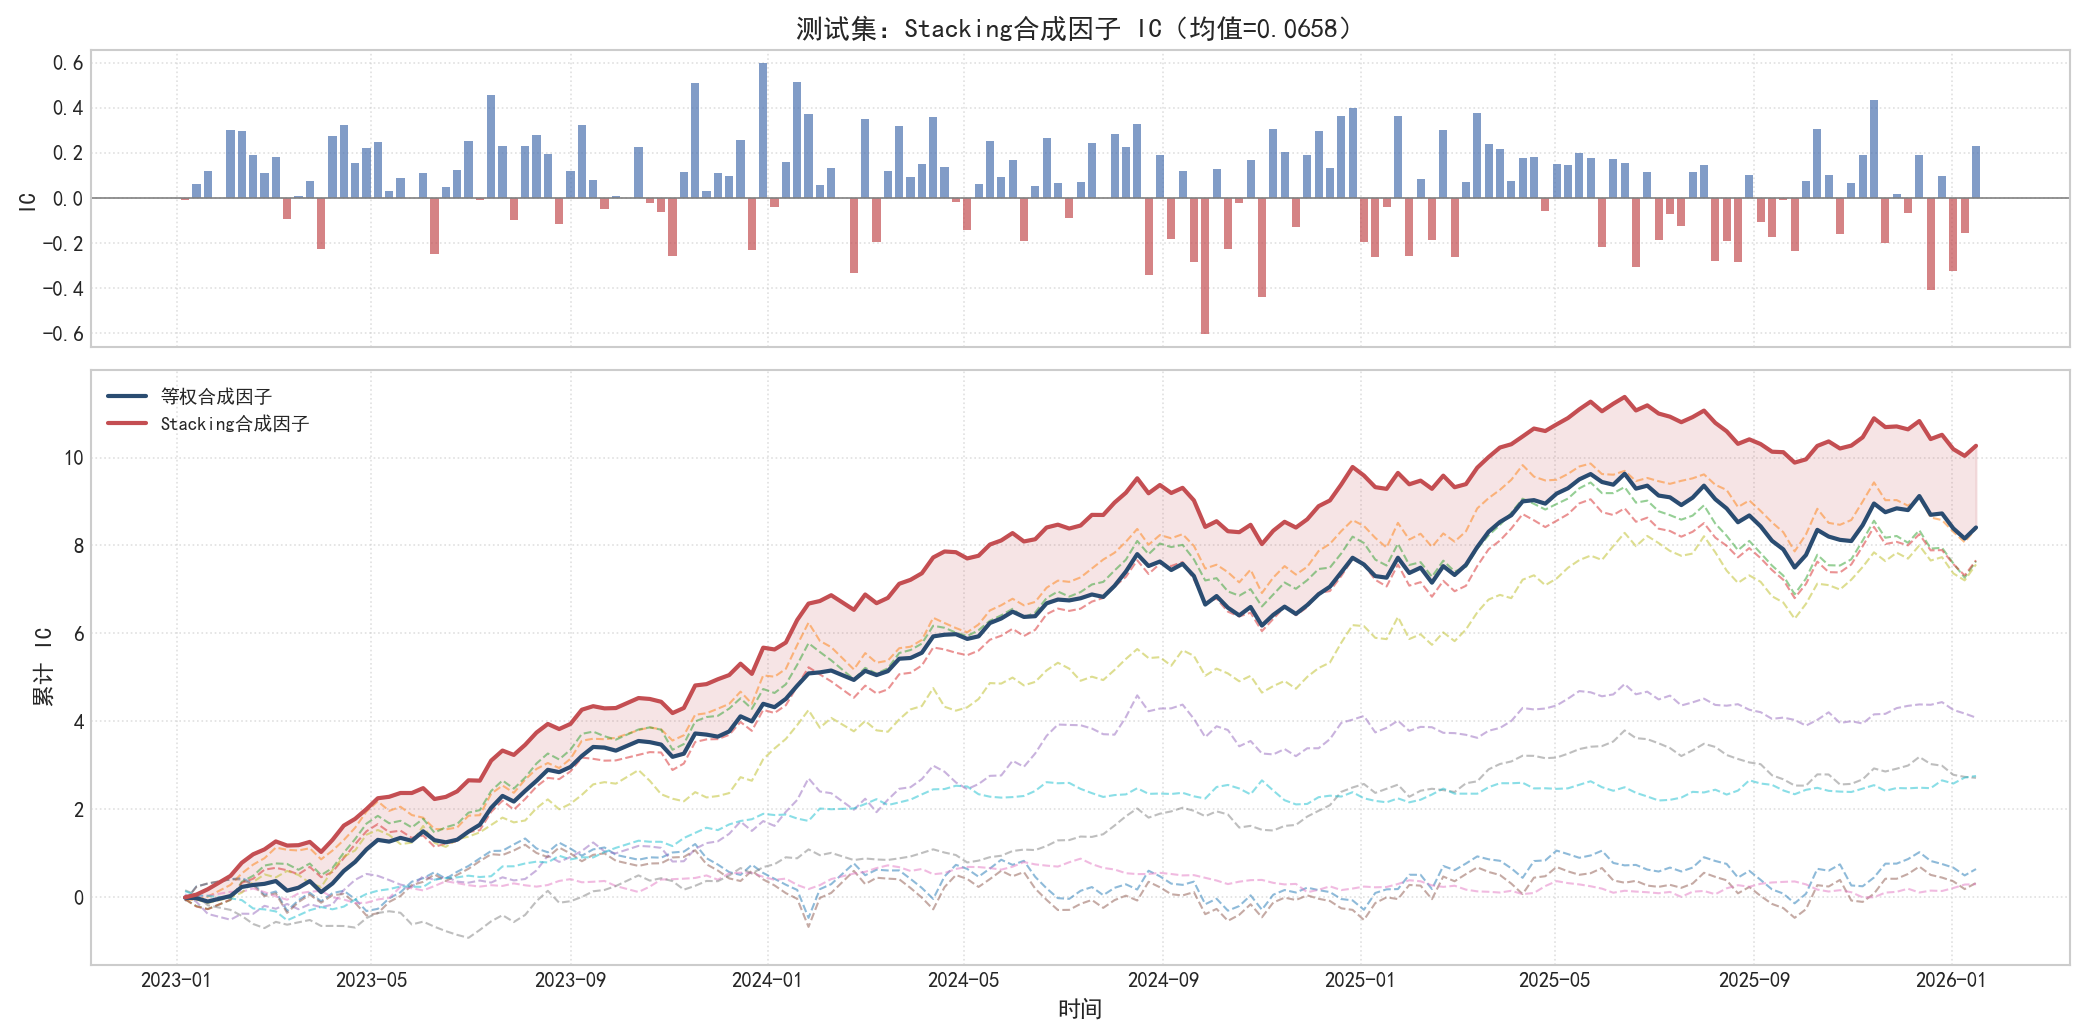

In [12]:
from scipy import stats

def calc_composite_ic(pred_df):
    ic_list = []
    for t, grp in pred_df.groupby('time'):
        valid = grp[['stacking_score', 'next_ret']].dropna()
        if len(valid) < 20:
            continue
        ic, _ = stats.spearmanr(valid['stacking_score'], valid['next_ret'])
        ic_list.append({'time': t, 'IC': ic})
    return pd.DataFrame(ic_list)

composite_ic = calc_composite_ic(pred_all)

# 测试集
test_start = pd.Timestamp('2023-01-01')
composite_ic_test = composite_ic[composite_ic['time'] >= test_start].copy()

# IC 统计
test_weekly_2023 = full_weekly[full_weekly['time'] >= test_start].copy()
# 截面Z-score标准化后相加得到等权因子
test_weekly_2023['eq_weight_score'] = test_weekly_2023.groupby('time', group_keys=False)[selected_factors].apply(lambda x: (x - x.mean()) / x.std(ddof=1)).mean(axis=1)

eval_factors = selected_factors + ['eq_weight_score']
ind_ic_df = calc_ic_series(test_weekly_2023, eval_factors, method='spearman', min_obs=20)

# 因子tvr计算
ind_tvr = calc_tvr_zscore(test_weekly_2023, eval_factors)

ind_IC = ind_ic_df.mean()
ind_IR = ind_ic_df.mean() / ind_ic_df.std()
summary_df = pd.DataFrame({'IC': ind_IC, 'IR': ind_IR, 'tvr': ind_tvr})

summary_df = summary_df.rename(index={'eq_weight_score': '等权合成因子'})

comp_mean = composite_ic_test['IC'].mean()
comp_std = composite_ic_test['IC'].std()
comp_IC = comp_mean
comp_IR = comp_IC / comp_std

# Stacking因子tvr计算
pred_test_for_tvr = pred_all[pred_all['time'] >= test_start].copy().sort_values(['code', 'time'])
comp_tvr = calc_tvr_zscore(pred_test_for_tvr, ['stacking_score'])['stacking_score']

summary_df.loc['Stacking合成因子'] = [comp_IC, comp_IR, comp_tvr]
summary_df = summary_df.sort_values('IC', ascending=False)

print("测试集 各因子与合成因子 IC 统计对比：")
display(summary_df)

# 合成因子累积IC
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), dpi=150, sharex=True,
                                gridspec_kw={'height_ratios': [1, 2]})

colors = ['#4C72B0' if x > 0 else '#C44E52' for x in composite_ic_test['IC']]
ax1.bar(composite_ic_test['time'], composite_ic_test['IC'], color=colors, alpha=0.7, width=5)
ax1.axhline(0, color='gray', linewidth=0.8)
ic_mean = composite_ic_test['IC'].mean()
ax1.set_title(f'测试集：Stacking合成因子 IC（均值={ic_mean:.4f}）', fontsize=13)
ax1.set_ylabel('IC', fontsize=11)
ax1.tick_params(labelsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)

cum_ic = composite_ic_test['IC'].cumsum().values
ind_cum_ic = ind_ic_df.cumsum().ffill().fillna(0)
for f in selected_factors:
    ax2.plot(ind_cum_ic.index, ind_cum_ic[f], linestyle='--', linewidth=1, alpha=0.5)

ax2.plot(ind_cum_ic.index, ind_cum_ic['eq_weight_score'], color='#2A4C71', linewidth=2, label='等权合成因子')
ax2.plot(composite_ic_test['time'], cum_ic, color='#C44E52', linewidth=2, label='Stacking合成因子')
ax2.fill_between(composite_ic_test['time'], ind_cum_ic['eq_weight_score'], cum_ic, alpha=0.15, color='#C44E52')
ax2.set_ylabel('累计 IC', fontsize=11)
ax2.set_xlabel('时间', fontsize=11)
ax2.tick_params(labelsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


### 2.6 合成因子分层回测

['time', 'level_1', 'code', 'next_ret', 'label', 'pred_class', 'stacking_score', 'quantile']
        time  quantile  next_ret
0 2023-01-06         1  0.022239
1 2023-01-06         5 -0.022976
2 2023-01-06         3  0.016361
3 2023-01-06         4  0.001838
4 2023-01-06         3  0.000000


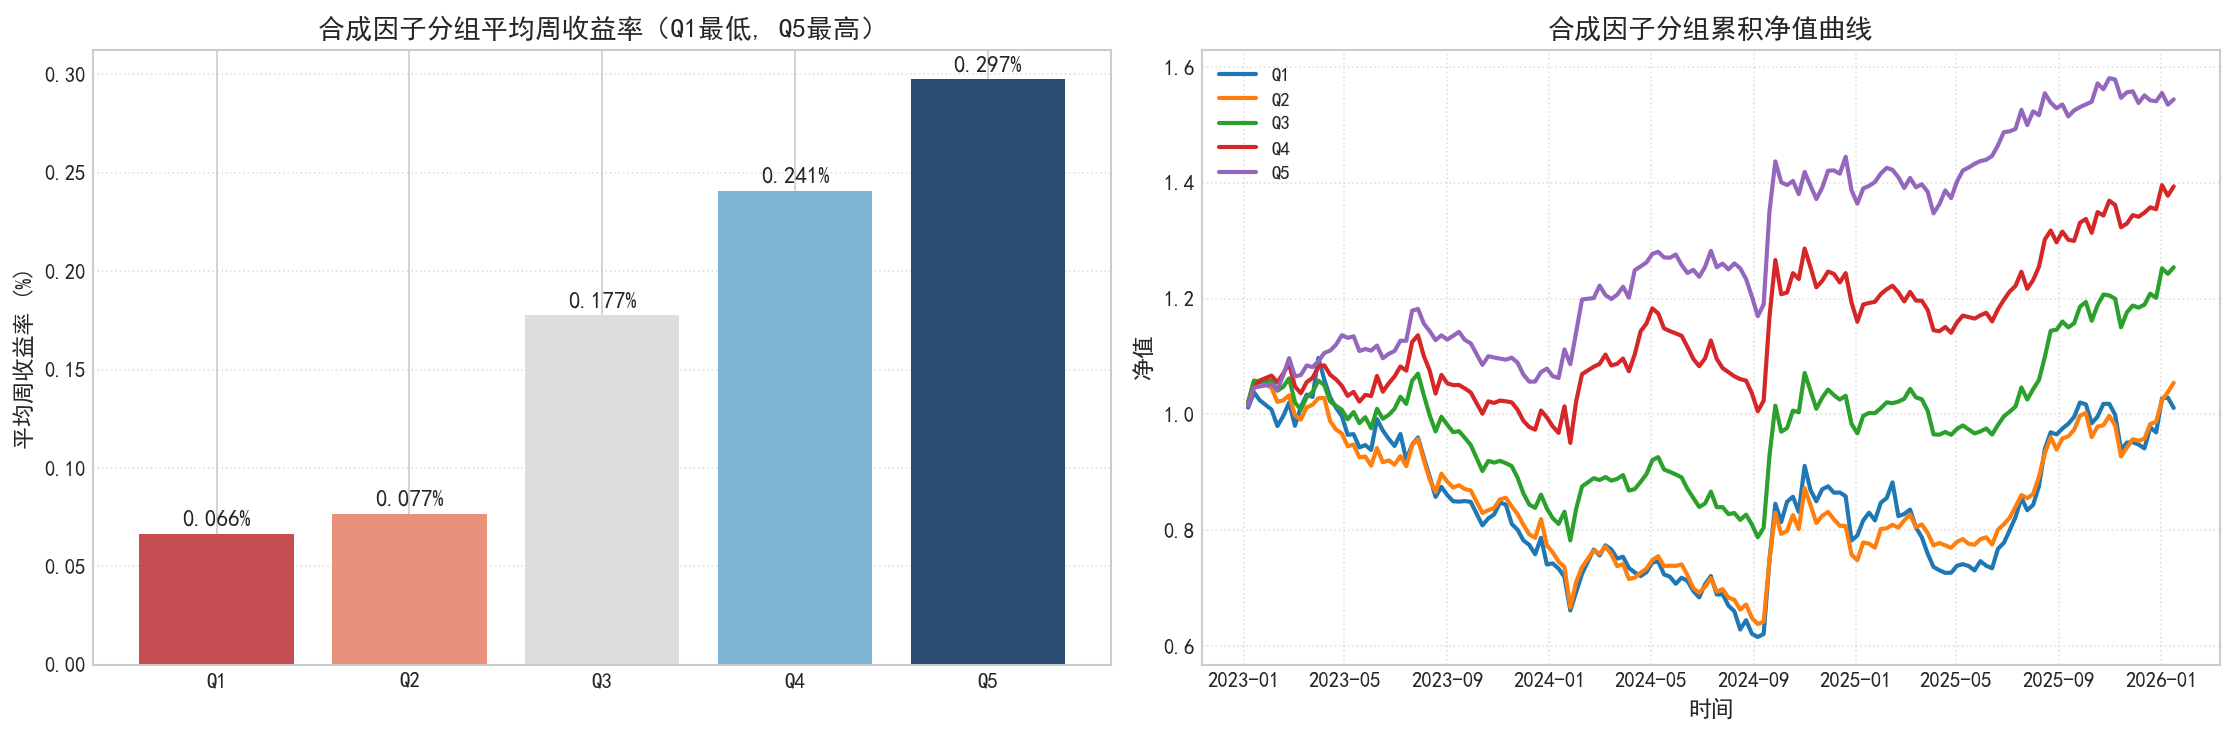

Q5-Q1 多空组合：年化收益 12.74%，周均收益 0.231%


In [14]:
# 合成因子分层回测（5组）
pred_test_q = pred_all[pred_all['time'] >= '2023-01-01'].copy()
# pred_test_q = pred_test_q.reset_index(drop=True)

def assign_quantile(grp, n_groups=5):
    grp = grp.copy()
    grp['quantile'] = pd.cut(
        grp['stacking_score'].rank(pct=True),
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=[1, 2, 3, 4, 5],
        include_lowest=True
    ).astype(int)
    return grp

pred_test_q = pred_test_q.groupby('time').apply(assign_quantile)
pred_test_q = pred_test_q.reset_index()

print(pred_test_q.columns.tolist())
print(pred_test_q[['time', 'quantile', 'next_ret']].head())

# 各组每周平均收益率
q_ret = pred_test_q.groupby(['time', 'quantile'])['next_ret'].mean().unstack()

# 累积净值
q_nav = (1 + q_ret).cumprod()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=150)

q_mean_ret = q_ret.mean() * 100
colors_q = ['#C44E52', '#E8927C', '#DDDDDD', '#7EB5D6', '#2A4C71']
bars = ax1.bar([f'Q{i}' for i in q_mean_ret.index], q_mean_ret.values, color=colors_q)
for bar in bars:
    h = bar.get_height()
    ax1.annotate(f'{h:.3f}%', xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 4), textcoords='offset points', ha='center', fontsize=11)
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_title('合成因子分组平均周收益率（Q1最低, Q5最高）', fontsize=13)
ax1.set_ylabel('平均周收益率 (%)', fontsize=11)
ax1.tick_params(labelsize=10)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

for col in q_nav.columns:
    ax2.plot(q_nav.index, q_nav[col], linewidth=2, label=f'Q{int(col)}')
ax2.set_title('合成因子分组累积净值曲线', fontsize=13)
ax2.set_ylabel('净值', fontsize=11)
ax2.set_xlabel('时间', fontsize=11)
ax2.tick_params(labelsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 多空收益
ls_ret = q_ret[5] - q_ret[1]
ls_nav = (1 + ls_ret).cumprod()
ann_ls = (1 + ls_ret.mean()) ** 52 - 1
print(f"Q5-Q1 多空组合：年化收益 {ann_ls:.2%}，周均收益 {ls_ret.mean()*100:.3f}%")

### 2.7 测试区间：PnL曲线

In [15]:
# 日频收益率矩阵
test_df = df[df['time'] >= '2023-01-01'].copy()
daily_ret = test_df.pivot(index='time', columns='code', values='ret').fillna(0)

# 基准：沪深300指数
hs300 = pd.read_excel("./Data/HS300_data/沪深300指数.xlsx")
hs300 = hs300[['日期', '沪深300指数']].copy()
hs300.columns = ['time', 'close']
hs300.dropna(inplace=True)
hs300['time'] = pd.to_datetime(hs300['time'])
hs300.set_index('time', inplace=True)
hs300.sort_index(inplace=True)
hs300['ret'] = hs300['close'].pct_change().fillna(0)
has_benchmark = True

# 周频
pred_test = pred_all[pred_all['time'] >= test_start].copy()
factor_pivot = pred_test.pivot(index='time', columns='code', values='stacking_score')
eq_pivot = test_weekly_2023.pivot(index='time', columns='code', values='eq_weight_score')

# 纯多头 Top-K 等权
TOP_K = 30
def get_long_only_weights(row, top_k=TOP_K):
    s = row.dropna()
    if len(s) < top_k:
        top_k_actual = max(1, len(s) // 3)
    else:
        top_k_actual = top_k
    top_codes = s.nlargest(top_k_actual).index
    w = pd.Series(0.0, index=row.index)
    w[top_codes] = 1.0 / top_k_actual
    return w

weekly_w_long = factor_pivot.apply(get_long_only_weights, axis=1)
daily_w_long = weekly_w_long.reindex(daily_ret.index).ffill().shift(1).fillna(0)
strat_daily_ret_long = (daily_w_long * daily_ret).sum(axis=1)
strat_nav_long = (1 + strat_daily_ret_long).cumprod()

weekly_w_eq = eq_pivot.apply(get_long_only_weights, axis=1)
daily_w_eq = weekly_w_eq.reindex(daily_ret.index).ffill().shift(1).fillna(0)
strat_daily_ret_eq = (daily_w_eq * daily_ret).sum(axis=1)
strat_nav_eq = (1 + strat_daily_ret_eq).cumprod()

# 基准
if has_benchmark:
    hs300_test = hs300.reindex(daily_ret.index).fillna(0)
    bench_daily_ret = hs300_test['ret']
else:
    bench_daily_ret = daily_ret.mean(axis=1)
bench_nav = (1 + bench_daily_ret).cumprod()

# 单因子
ind_strat_daily_ret = {}
ind_strat_nav = {}
for f in selected_factors:
    f_pivot = test_weekly_2023.pivot(index='time', columns='code', values=f)
    w_long = f_pivot.apply(get_long_only_weights, axis=1)
    w_daily = w_long.reindex(daily_ret.index).ffill().shift(1).fillna(0)
    f_daily_ret = (w_daily * daily_ret).sum(axis=1)
    ind_strat_daily_ret[f] = f_daily_ret
    ind_strat_nav[f] = (1 + f_daily_ret).cumprod()


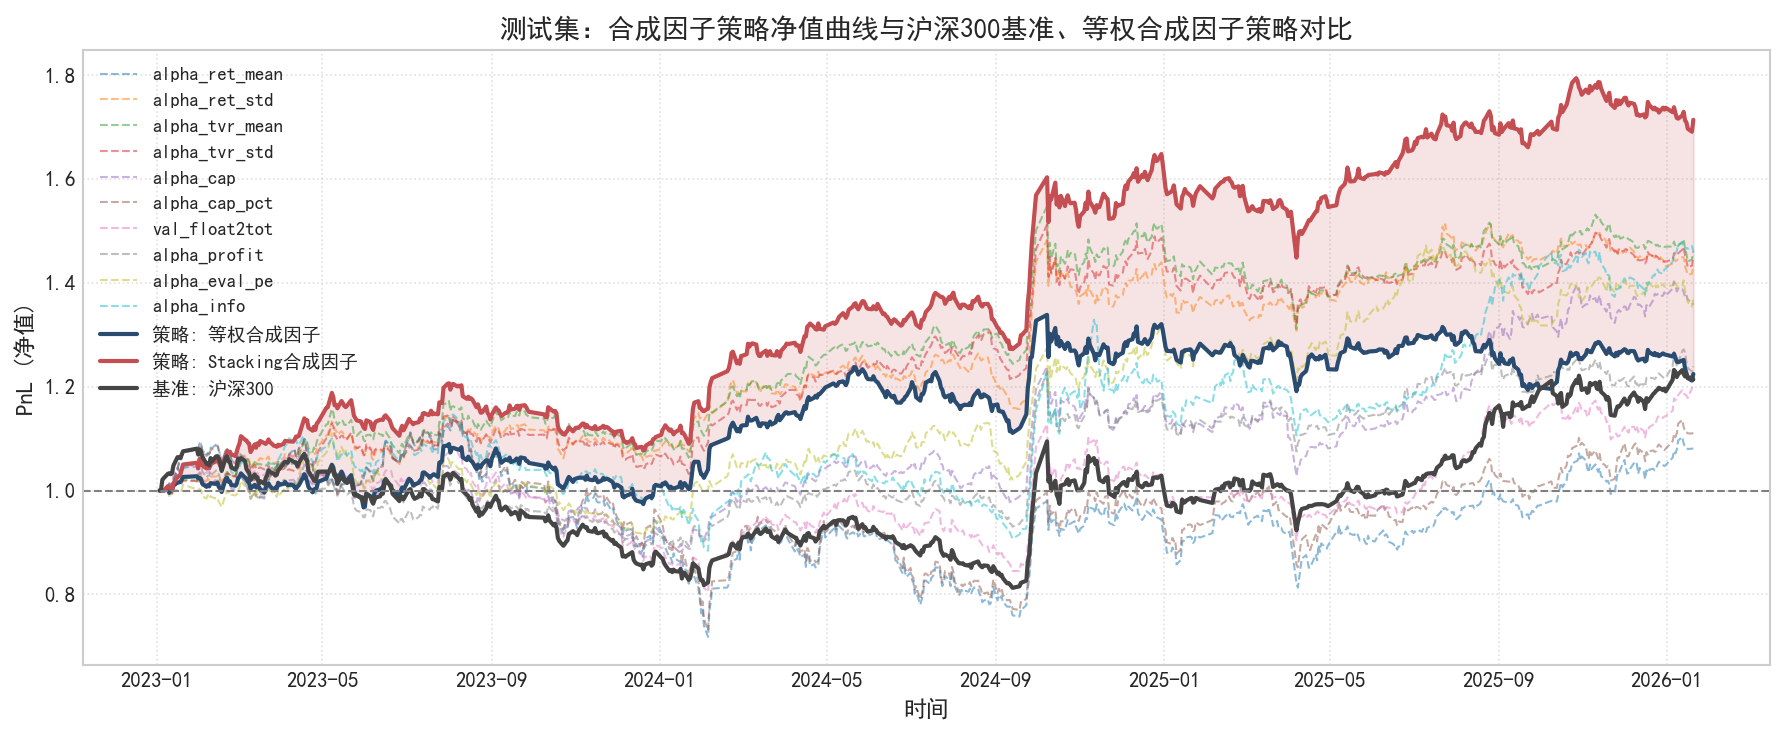

In [17]:
plt.figure(figsize=(12, 5), dpi=150)

for f in selected_factors:
    plt.plot(ind_strat_nav[f].index, ind_strat_nav[f],
             label=f'{f}', linestyle='--', linewidth=1, alpha=0.5)

plt.plot(strat_nav_eq.index, strat_nav_eq,
         label='策略: 等权合成因子', color='#2A4C71', linewidth=2)
plt.plot(strat_nav_long.index, strat_nav_long,
         label='策略: Stacking合成因子', color='#C44E52', linewidth=2)
plt.fill_between(strat_nav_long.index, strat_nav_eq, strat_nav_long, color='#C44E52', alpha=0.15)
plt.plot(bench_nav.index, bench_nav,
         label='基准: 沪深300', color='#454545', linewidth=2)

plt.axhline(1, linestyle='--', color='gray', linewidth=1)
plt.title('测试集：合成因子策略净值曲线与沪深300基准、等权合成因子策略对比', fontsize=13)
plt.xlabel('时间', fontsize=11)
plt.ylabel('PnL (净值)', fontsize=11)
plt.tick_params(labelsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()


In [18]:
def calc_metrics(daily_rets, label):
    daily_mean = daily_rets.mean()
    daily_std = daily_rets.std(ddof=1)
    ann_ret = (1 + daily_mean) ** 252 - 1
    ann_std = daily_std * np.sqrt(252)
    sharpe = (ann_ret - 0.02742) / ann_std if ann_std != 0 else np.nan
    nav = (1 + daily_rets).cumprod()
    roll_max = nav.cummax()
    max_dd = (nav / roll_max - 1).min()
    return {
        '因子/基准': label,
        '日收益率': f"{daily_mean:.4%}",
        '日收益率标准差': f"{daily_std:.4%}",
        '年化收益率': f"{ann_ret:.2%}",
        '夏普比率': f"{sharpe:.2f}",
        '最大回撤': f"{max_dd:.2%}",
    }

metrics_list = []
metrics_list.append(calc_metrics(strat_daily_ret_long, 'Stacking合成'))
metrics_list.append(calc_metrics(strat_daily_ret_eq, '等权合成因子'))

for f in selected_factors:
    metrics_list.append(calc_metrics(ind_strat_daily_ret[f], f))

metrics_list.append(calc_metrics(bench_daily_ret, '沪深300基准'))

metrics_df = pd.DataFrame(metrics_list)
# 用夏普排序
metrics_df['夏普_num'] = metrics_df['夏普比率'].astype(float)
metrics_df = metrics_df.sort_values('夏普_num', ascending=False).drop('夏普_num', axis=1).reset_index(drop=True)

print("\n测试集绩效统计:")
display(metrics_df)




测试集绩效统计:


,因子/基准,日收益率,日收益率标准差,年化收益率,夏普比率,最大回撤
0,Stacking合成,0.0767%,0.8686%,21.31%,1.35,-12.11%
1,alpha_tvr_mean,0.0552%,0.8821%,14.91%,0.87,-15.25%
2,alpha_ret_std,0.0522%,0.8294%,14.06%,0.86,-11.78%
3,alpha_tvr_std,0.0542%,0.8847%,14.62%,0.85,-12.76%
4,alpha_info,0.0584%,1.1963%,15.84%,0.69,-22.91%
5,alpha_eval_pe,0.0477%,1.0000%,12.76%,0.63,-17.79%
6,alpha_cap,0.0463%,0.9929%,12.38%,0.61,-17.00%
7,alpha_profit,0.0338%,0.9835%,8.89%,0.39,-15.85%
8,等权合成因子,0.0312%,0.8670%,8.17%,0.39,-10.98%
9,沪深300基准,0.0319%,1.0704%,8.37%,0.33,-24.80%


In [19]:
# CSV输出
import os
OUT = './Output/Hw5'
os.makedirs(OUT, exist_ok=True)

# 因子取值
factor_out = pred_test[['time', 'code', 'stacking_score']].copy()
factor_out = factor_out.rename(columns={'stacking_score': 'composite_factor'})
factor_out = factor_out.sort_values(['time', 'code'])
factor_out.to_csv(f'{OUT}/因子取值计算结果.csv', index=False, encoding='utf-8-sig')

# 策略权重
weights_out = factor_out[['time', 'code']].copy()
w_long_df = weekly_w_long.stack().reset_index()
w_long_df.columns = ['time', 'code', 'weight']
weights_out = pd.merge(weights_out, w_long_df, on=['time', 'code'], how='left')
weights_out = weights_out.sort_values(['time', 'code'])
weights_out.to_csv(f'{OUT}/因子策略权重结果.csv', index=False, encoding='utf-8-sig')

# 因子IC
ic_out = composite_ic_test[['time', 'IC']].copy()
ic_out.to_csv(f'{OUT}/因子IC结果.csv', index=False, encoding='utf-8-sig')

# 策略日收益率
ret_out = pd.DataFrame({
    'time': strat_daily_ret_long.index,
    'strategy_return': strat_daily_ret_long.values
})
ret_out.to_csv(f'{OUT}/策略日收益率结果.csv', index=False, encoding='utf-8-sig')